In [73]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import norm

In [74]:
BAYER = pd.read_csv(r'C:\Users\Mus\Downloads\Bayer Stock Price History.csv')
DAX = pd.read_csv(r'C:\Users\Mus\Downloads\DAX Historical Data.csv')
DE10 = pd.read_csv(r'C:\Users\Mus\Downloads\Germany 10-Year Bond Yield Historical Data.csv')

**Data Cleaning**

In [75]:
def clean_data(df):
    df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')
    if df['Price'].dtype == 'object':  # only clean if it's text
        df['Price'] = df['Price'].str.replace(',', '').astype(float)
    df = df.sort_values('Date').reset_index(drop=True)
    df = df[['Date', 'Price']]
    return df

In [76]:
BAYER = clean_data(BAYER)
DAX = clean_data(DAX)
DE10 = clean_data(DE10)

In [77]:
df = BAYER.merge(DAX,on='Date',suffixes=('_BAYER','_DAX'))
df = df.merge(DE10, on='Date')
df = df.rename(columns={'Price':'Price_DE10'})

**Statistical Computation**

In [78]:
df['Return_BAYER'] = df['Price_BAYER'].pct_change()
df['Return_DAX'] = df['Price_DAX'].pct_change()

In [79]:
df = df.dropna().reset_index(drop=True)

In [80]:
print('Bayer mean:', df['Return_BAYER'].mean())
print('Bayer std:', df['Return_BAYER'].std())
print('DAX mean:', df['Return_DAX'].mean())
print('DAX std:', df['Return_DAX'].std())
print('Correlation:', df['Return_BAYER'].corr(df['Return_DAX']))

Bayer mean: -0.0003699572085741213
Bayer std: 0.09713141051896629
DAX mean: 0.008016046050153578
DAX std: 0.04264542213070974
Correlation: 0.35812940293846146


In [81]:
print('Bayer rows:', len(BAYER), '| First:', BAYER['Date'].iloc[0], '| Last:', BAYER['Date'].iloc[-1])
print('DAX rows:', len(DAX), '| First:', DAX['Date'].iloc[0], '| Last:', DAX['Date'].iloc[-1])
print('DE10 rows:', len(DE10), '| First:', DE10['Date'].iloc[0], '| Last:', DE10['Date'].iloc[-1])
print('Observations after merge:', len(df))

Bayer rows: 61 | First: 2021-04-01 00:00:00 | Last: 2026-04-01 00:00:00
DAX rows: 61 | First: 2021-04-01 00:00:00 | Last: 2026-04-01 00:00:00
DE10 rows: 61 | First: 2021-04-01 00:00:00 | Last: 2026-04-01 00:00:00
Observations after merge: 60


In [82]:
print('Start:', df['Date'].min())
print('End:', df['Date'].max())
print('Number of observations:', len(df))
print()
print('Bayer mean:', round(df['Return_BAYER'].mean() * 100,2), '%')
print('Bayer std:', round(df['Return_BAYER'].std() * 100,2), '%')
print('DAX mean:', round(df['Return_DAX'].mean() * 100,2), '%')
print('DAX std:', round(df['Return_DAX'].std() * 100,2), '%')
print('Correlation:', round(df['Return_BAYER'].corr(df['Return_DAX']),2))

Start: 2021-05-01 00:00:00
End: 2026-04-01 00:00:00
Number of observations: 60

Bayer mean: -0.04 %
Bayer std: 9.71 %
DAX mean: 0.8 %
DAX std: 4.26 %
Correlation: 0.36


In [83]:
df['Risk free rate'] = df['Price_DE10'] / 100 / 12
df['Excess_BAYER'] = df['Return_BAYER'] - df['Risk free rate']
df['Excess_DAX'] = df['Return_DAX'] - df['Risk free rate']

**OLS Result**

In [84]:
X = sm.add_constant(df['Excess_DAX'])
y = df['Excess_BAYER']
model = sm.OLS(y,X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           Excess_BAYER   R-squared:                       0.128
Model:                            OLS   Adj. R-squared:                  0.113
Method:                 Least Squares   F-statistic:                     8.539
Date:                Sun, 05 Apr 2026   Prob (F-statistic):            0.00495
Time:                        13:57:50   Log-Likelihood:                 59.382
No. Observations:                  60   AIC:                            -114.8
Df Residuals:                      58   BIC:                            -110.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0072      0.012     -0.604      0.5

**Return Visualization**

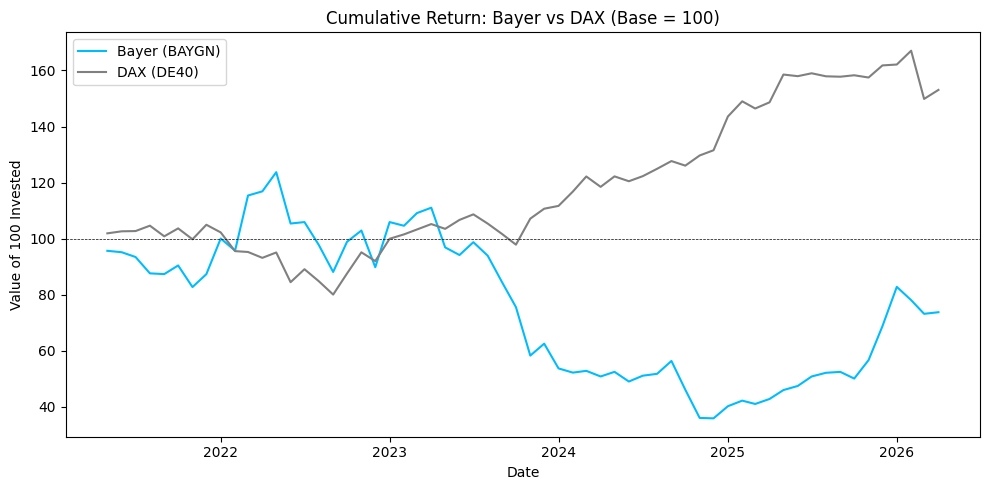

In [85]:
cumulative_bayer = (1 + df['Return_BAYER']).cumprod() * 100
cumulative_dax = (1 + df['Return_DAX']).cumprod() * 100

plt.figure(figsize=(10, 5))
plt.plot(df['Date'], cumulative_bayer, label='Bayer (BAYGN)', color='#00bcff')
plt.plot(df['Date'], cumulative_dax, label='DAX (DE40)', color='gray')
plt.axhline(y=100, color='black', linestyle='--', linewidth=0.5)
plt.title('Cumulative Return: Bayer vs DAX (Base = 100)')
plt.xlabel('Date')
plt.ylabel('Value of 100 Invested')
plt.legend()
plt.tight_layout()
plt.savefig('cumulative_return.png', dpi=300)
plt.show()

**CAPM Regression**

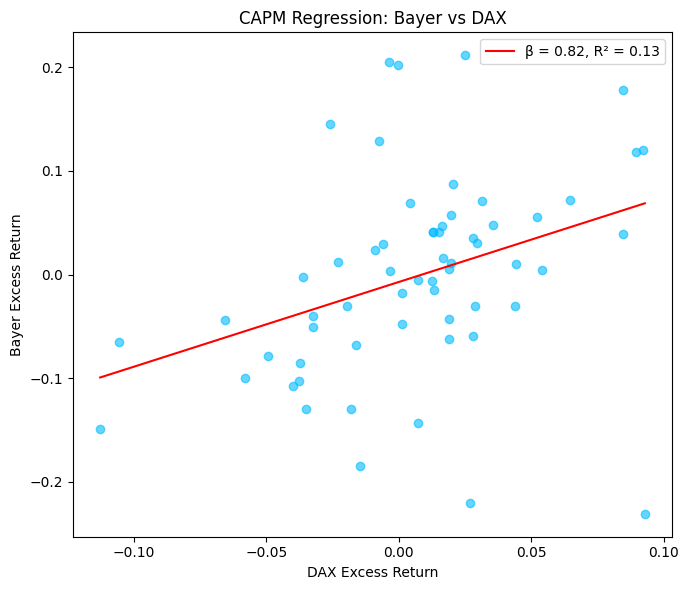

In [86]:
plt.figure(figsize=(7, 6))
plt.scatter(df['Excess_DAX'], df['Excess_BAYER'], alpha=0.6, color='#00bcff')

# Regression line
import numpy as np
x_line = np.linspace(df['Excess_DAX'].min(), df['Excess_DAX'].max(), 100)
y_line = model.params['const'] + model.params['Excess_DAX'] * x_line
plt.plot(x_line, y_line, color='red', label=f'β = {model.params["Excess_DAX"]:.2f}, R² = {model.rsquared:.2f}')

plt.title('CAPM Regression: Bayer vs DAX')
plt.xlabel('DAX Excess Return')
plt.ylabel('Bayer Excess Return')
plt.legend()
plt.tight_layout()
plt.savefig('capm_scatter.png', dpi=300)
plt.show()

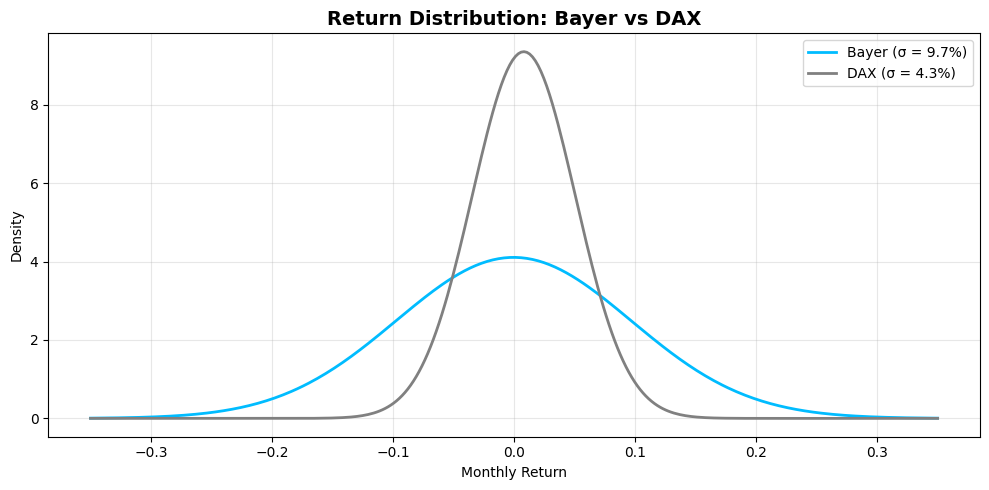

In [72]:
fig, ax = plt.subplots(figsize=(10, 5))

x_range = np.linspace(-0.35, 0.35, 300)

# Bayer distribution
bayer_mean = df['Return_BAYER'].mean()
bayer_std = df['Return_BAYER'].std()
ax.plot(x_range, norm.pdf(x_range, bayer_mean, bayer_std), 
        label=f'Bayer (σ = {bayer_std*100:.1f}%)', color='#00bcff', linewidth=2)

# DAX distribution
dax_mean = df['Return_DAX'].mean()
dax_std = df['Return_DAX'].std()
ax.plot(x_range, norm.pdf(x_range, dax_mean, dax_std), 
        label=f'DAX (σ = {dax_std*100:.1f}%)', color='gray', linewidth=2)

ax.set_title('Return Distribution: Bayer vs DAX', fontsize=14, fontweight='bold')
ax.set_xlabel('Monthly Return')
ax.set_ylabel('Density')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig('distribution.png', dpi=300)
plt.show()